In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df.shape

(1000, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


C:\Users\kumar\AppData\Local\Temp\ipykernel_24400\2175639046.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["cgpa"])
C:\Users\kumar\AppData\Local\Temp\ipykernel_24400\2175639046.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["placement_exam_marks"])


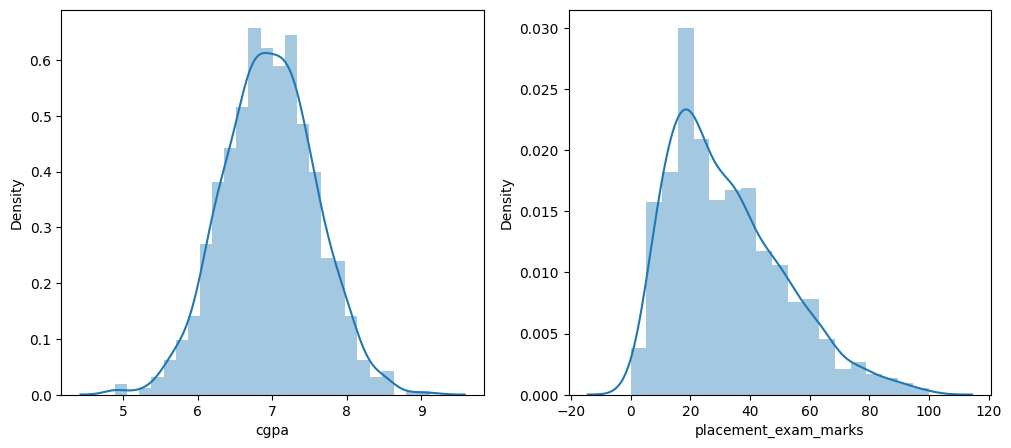

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.distplot(df["cgpa"])

plt.subplot(122)
sns.distplot(df["placement_exam_marks"])

plt.show()

In [9]:
# from above 
# cgpa is normally disrubuted we can use Z-score method for the outlier removal
# placement is right skewed then we will use IQR method in this column for out removal  

In [11]:
df["placement_exam_marks"].skew()

0.8356419499466834

In [12]:
df["cgpa"].skew()

-0.014529938929314918

In [14]:
df["placement_exam_marks"].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

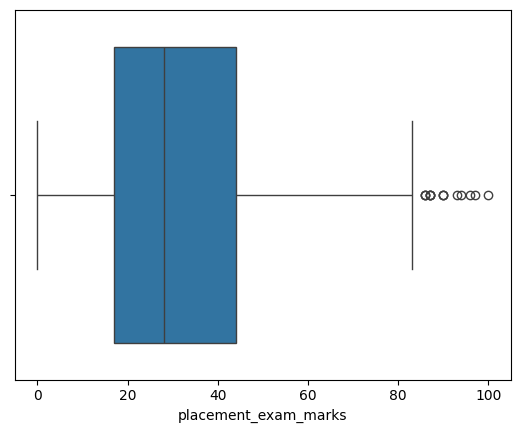

In [16]:
sns.boxplot(df , x = df["placement_exam_marks"])

In [17]:
percentile25 = df["placement_exam_marks"].quantile(0.25)
percentile75 = df["placement_exam_marks"].quantile(0.75)

In [18]:
percentile25, percentile75

(17.0, 44.0)

In [19]:
iqr = percentile75-percentile25

In [20]:
iqr

27.0

In [21]:
uper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [22]:
uper_limit, lower_limit

(84.5, -23.5)

# Trimming

In [28]:
df[df["placement_exam_marks"] > uper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [27]:
df[df["placement_exam_marks"] < lower_limit]

,cgpa,placement_exam_marks,placed


In [29]:
new_df = df[df["placement_exam_marks"] < uper_limit]

In [30]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [31]:
new_df.shape

(985, 3)

C:\Users\kumar\AppData\Local\Temp\ipykernel_24400\224769524.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["placement_exam_marks"])
C:\Users\kumar\AppData\Local\Temp\ipykernel_24400\224769524.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df["placement_exam_marks"])


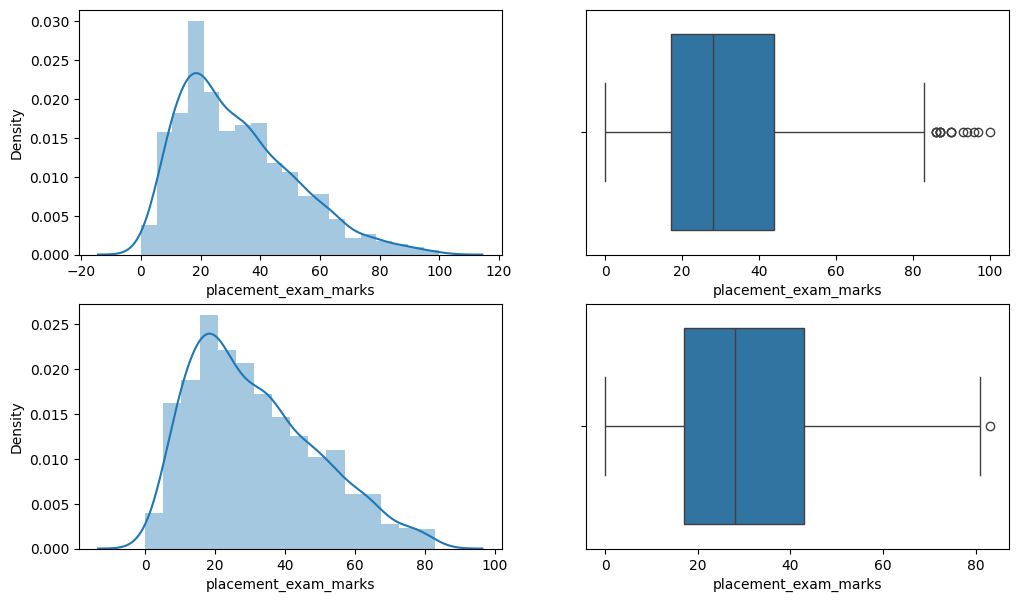

In [48]:
plt.figure(figsize=(12,7))

plt.subplot(221)
sns.distplot(df["placement_exam_marks"])

plt.subplot(222)
sns.boxplot(df, x = df["placement_exam_marks"])

plt.subplot(223)
sns.distplot(new_df["placement_exam_marks"])

plt.subplot(224)
sns.boxplot(new_df, x = new_df["placement_exam_marks"])

plt.show()

# Capping

In [42]:
new_df_cap = df.copy()

In [43]:
new_df_cap["placement_exam_marks"] = np.where(
    new_df_cap["placement_exam_marks"] > uper_limit, uper_limit,
    np.where(new_df_cap["placement_exam_marks"] < lower_limit, lower_limit,
    new_df_cap["placement_exam_marks"])
)

In [44]:
new_df_cap

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [46]:
new_df_cap["placement_exam_marks"].describe()

count    1000.000000
mean       32.136500
std        18.865419
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max        84.500000
Name: placement_exam_marks, dtype: float64

C:\Users\kumar\AppData\Local\Temp\ipykernel_24400\3664306144.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["placement_exam_marks"])
C:\Users\kumar\AppData\Local\Temp\ipykernel_24400\3664306144.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap["placement_exam_marks"])


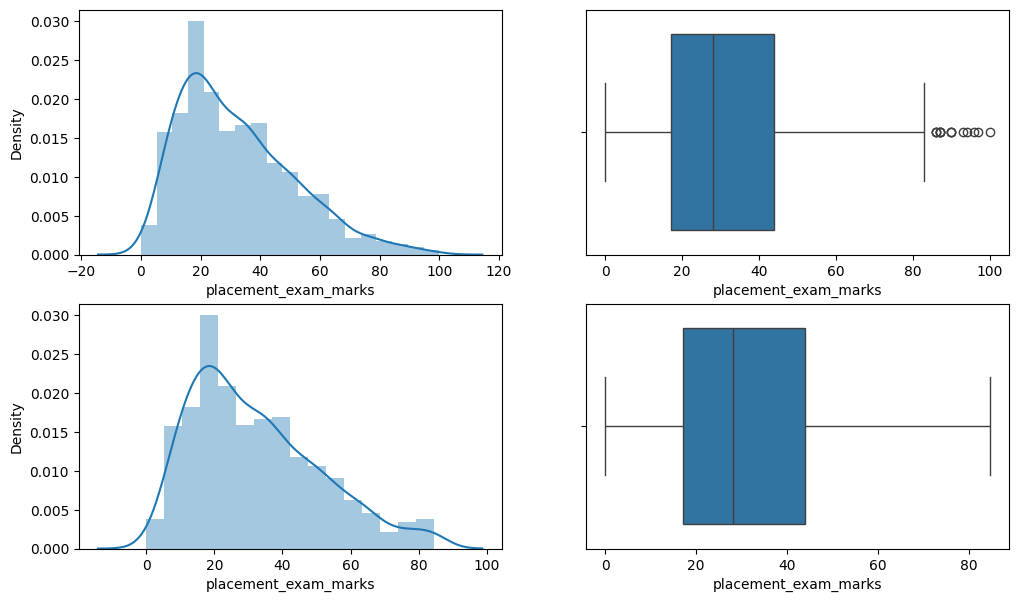

In [49]:
plt.figure(figsize=(12,7))

plt.subplot(221)
sns.distplot(df["placement_exam_marks"])

plt.subplot(222)
sns.boxplot(df, x = df["placement_exam_marks"])

plt.subplot(223)
sns.distplot(new_df_cap["placement_exam_marks"])

plt.subplot(224)
sns.boxplot(new_df_cap, x = new_df_cap["placement_exam_marks"])

plt.show()